# Music Genre Classification - `energy`

## Preparation

### Import necessary libraries

In [1]:
import sys
import pandas as pd
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from model.catboost import catboost
from model.xgboost import xgboost
from model.lightgbm import lightgbm
from model.randomforest import randomforest

### Load the dataset

In [2]:
data_dir = join('..', '..', 'data')
input_dir = join(data_dir, 'preprocessed')
train = pd.read_csv(join(input_dir, 'preprocessed_train.csv'))
test = pd.read_csv(join(input_dir, 'preprocessed_test.csv'))
train.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,-0.676218,9.0,0.153284,0,26.246030,0.723043,0.003912,-0.598627,0.235,1.014464,452.710724,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.256062,11.0,0.523145,1,11.415395,0.300739,0.045738,-0.629790,0.380,0.425560,438.127835,4,6
2,3,Royal & the Serpent,phuck u,44.0,0.584,0.550185,7.0,0.332191,1,16.154828,0.098922,0.139563,1.055408,0.635,1.226456,401.294156,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,-1.433464,-1.0,-1.572682,1,32.050255,0.967986,0.021076,1.134827,0.501,1.563116,545.978937,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.408517,6.0,0.691321,0,4.016048,0.567741,0.003912,0.583192,0.619,-1.217968,504.127960,4,5


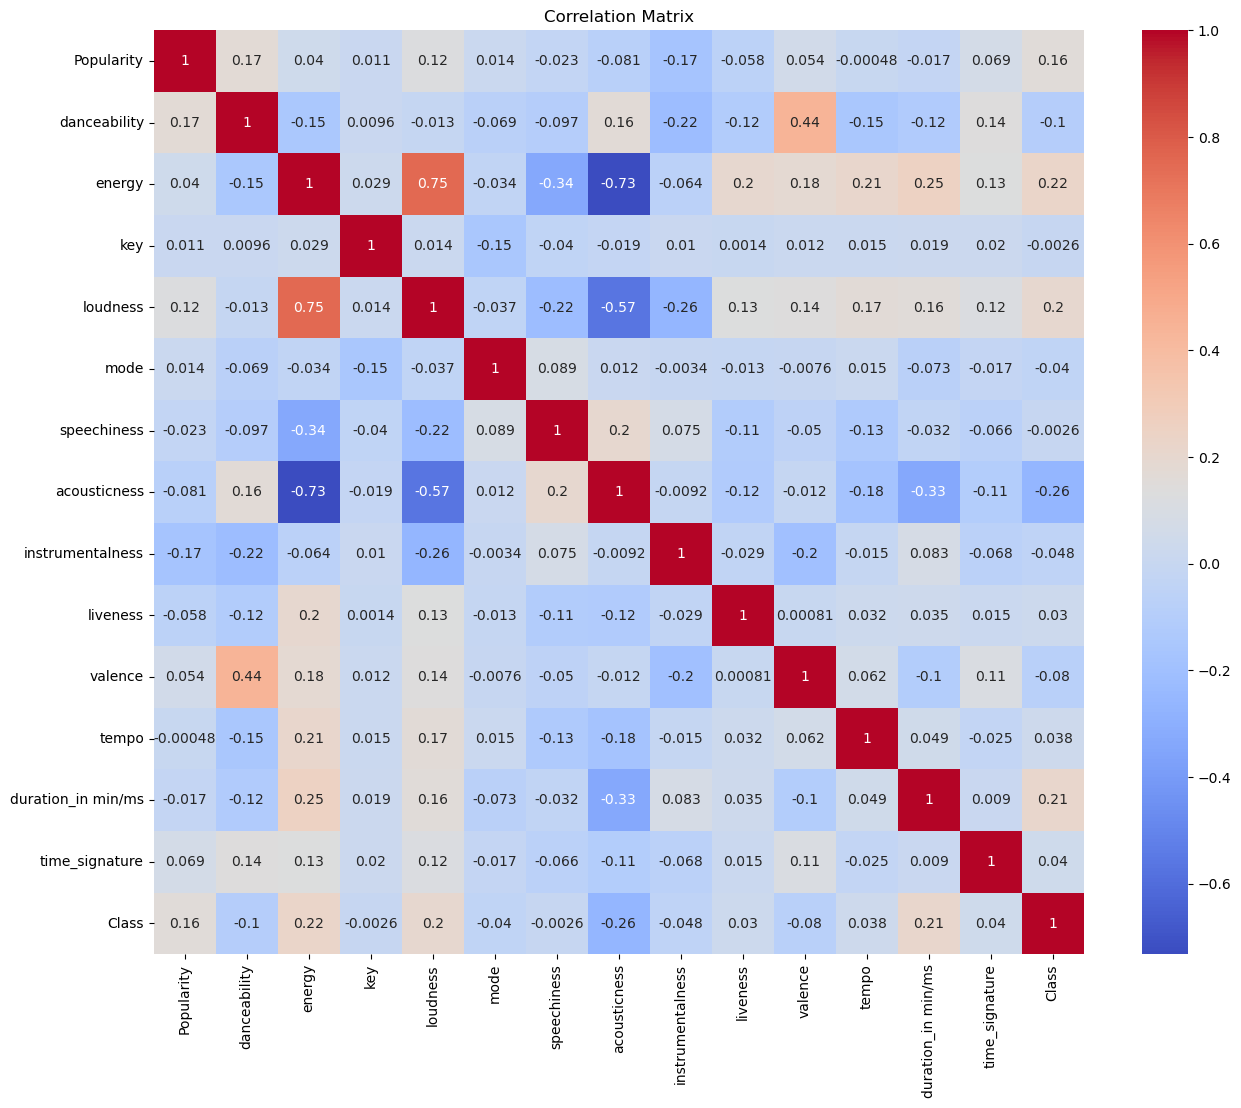

In [3]:
plt.figure(figsize=(15,12))
sns.heatmap(train.drop(['Artist Name', 'Track Name', 'Id'], axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Based on the correlation heatmap, we can see that the feature `energy` has the highest correlation with `Class` feature, and it does have high correlation with other features (`loudness`, `speechiness`, `acousticness`,...). 

In this notebook, we will dive deep into this feature.

## Have a look at the dataset

### Data description

- `energy`: A measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.
- `loudness` (dB): Loudness values are averaged across the entire track and are useful for comparing relative
- `speechiness`: The presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.
- `accousticness`: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.
- `duration_in min/ms`: Time of the song
- `tempo` (BPM): In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration.
- `liveness`: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.

Based on the correlation matrix, we can see that `acousticness` and `speechiness` has negative score compared with `evergy`, which means that the more energy the track has, the less speech-like the recordings are.

## Experiments

### Training models using 7 features

In [4]:
train = train[['Class', 'energy', 'loudness', 'speechiness', 'acousticness', 'duration_in min/ms', 'tempo', 'liveness']]
test = test[['energy', 'loudness', 'speechiness', 'acousticness', 'duration_in min/ms', 'tempo', 'liveness']]
train.head()

,Class,energy,loudness,speechiness,acousticness,duration_in min/ms,tempo,liveness
0,9,-0.676218,0.153284,26.246030,0.723043,452.710724,1.014464,-0.598627
1,6,0.256062,0.523145,11.415395,0.300739,438.127835,0.425560,-0.629790
2,10,0.550185,0.332191,16.154828,0.098922,401.294156,1.226456,1.055408
3,2,-1.433464,-1.572682,32.050255,0.967986,545.978937,1.563116,1.134827
4,5,0.408517,0.691321,4.016048,0.567741,504.127960,-1.217968,0.583192


In [5]:
catboost(df=train, df_test=test)

KeyboardInterrupt: 

In [ ]:
xgboost(df=train, df_test=test)


==== Fold 1 results for XGBClassifier ====
Fold 1 -> acc:0.3944 | prec:0.4399 | rec:0.4152 | f1:0.4212

==== Fold 2 results for XGBClassifier ====
Fold 2 -> acc:0.4053 | prec:0.4352 | rec:0.4200 | f1:0.4229

==== Fold 3 results for XGBClassifier ====
Fold 3 -> acc:0.4088 | prec:0.4430 | rec:0.4273 | f1:0.4317

==== Fold 4 results for XGBClassifier ====
Fold 4 -> acc:0.4015 | prec:0.4273 | rec:0.4215 | f1:0.4214

==== Fold 5 results for XGBClassifier ====
Fold 5 -> acc:0.4130 | prec:0.4405 | rec:0.4263 | f1:0.4283

==== Mean metrics ====
Acc: 0.4046
Prec: 0.4372
F1: 0.4251
Rec: 0.4221


In [ ]:
lightgbm(df=train, df_test=test)


==== Fold 1 results for LGBMClassifier ====
Fold 1 -> acc:0.4108 | prec:0.4534 | rec:0.4233 | f1:0.4306

==== Fold 2 results for LGBMClassifier ====
Fold 2 -> acc:0.4053 | prec:0.4230 | rec:0.4043 | f1:0.4090

==== Fold 3 results for LGBMClassifier ====
Fold 3 -> acc:0.4137 | prec:0.4417 | rec:0.4224 | f1:0.4274

==== Fold 4 results for LGBMClassifier ====
Fold 4 -> acc:0.4231 | prec:0.4529 | rec:0.4357 | f1:0.4391

==== Fold 5 results for LGBMClassifier ====
Fold 5 -> acc:0.4168 | prec:0.4390 | rec:0.4195 | f1:0.4234

==== Mean metrics ====
Acc: 0.4139
Prec: 0.4420
F1: 0.4259
Rec: 0.4210


In [ ]:
randomforest(df=train, df_test=test)


==== Fold 1 results for RandomForestClassifier ====
Fold 1 -> acc:0.4253 | prec:0.4655 | rec:0.4347 | f1:0.4358

==== Fold 2 results for RandomForestClassifier ====
Fold 2 -> acc:0.4349 | prec:0.4570 | rec:0.4400 | f1:0.4392

==== Fold 3 results for RandomForestClassifier ====
Fold 3 -> acc:0.4286 | prec:0.4399 | rec:0.4292 | f1:0.4288

==== Fold 4 results for RandomForestClassifier ====
Fold 4 -> acc:0.4415 | prec:0.4588 | rec:0.4618 | f1:0.4547

==== Fold 5 results for RandomForestClassifier ====
Fold 5 -> acc:0.4394 | prec:0.4495 | rec:0.4392 | f1:0.4337

==== Mean metrics ====
Acc: 0.4339
Prec: 0.4541
F1: 0.4385
Rec: 0.4410


From the result, we can see that the result is actually lower than that of baseline. It is clear that using only high correlation variables to train tree-based model does not usually give high accuracy.

### Training models (removing unimportant features)

To have an image of the importance of features, we will use model pickle files saved on baseline progress to analyze and find which features are the most important and which are least important

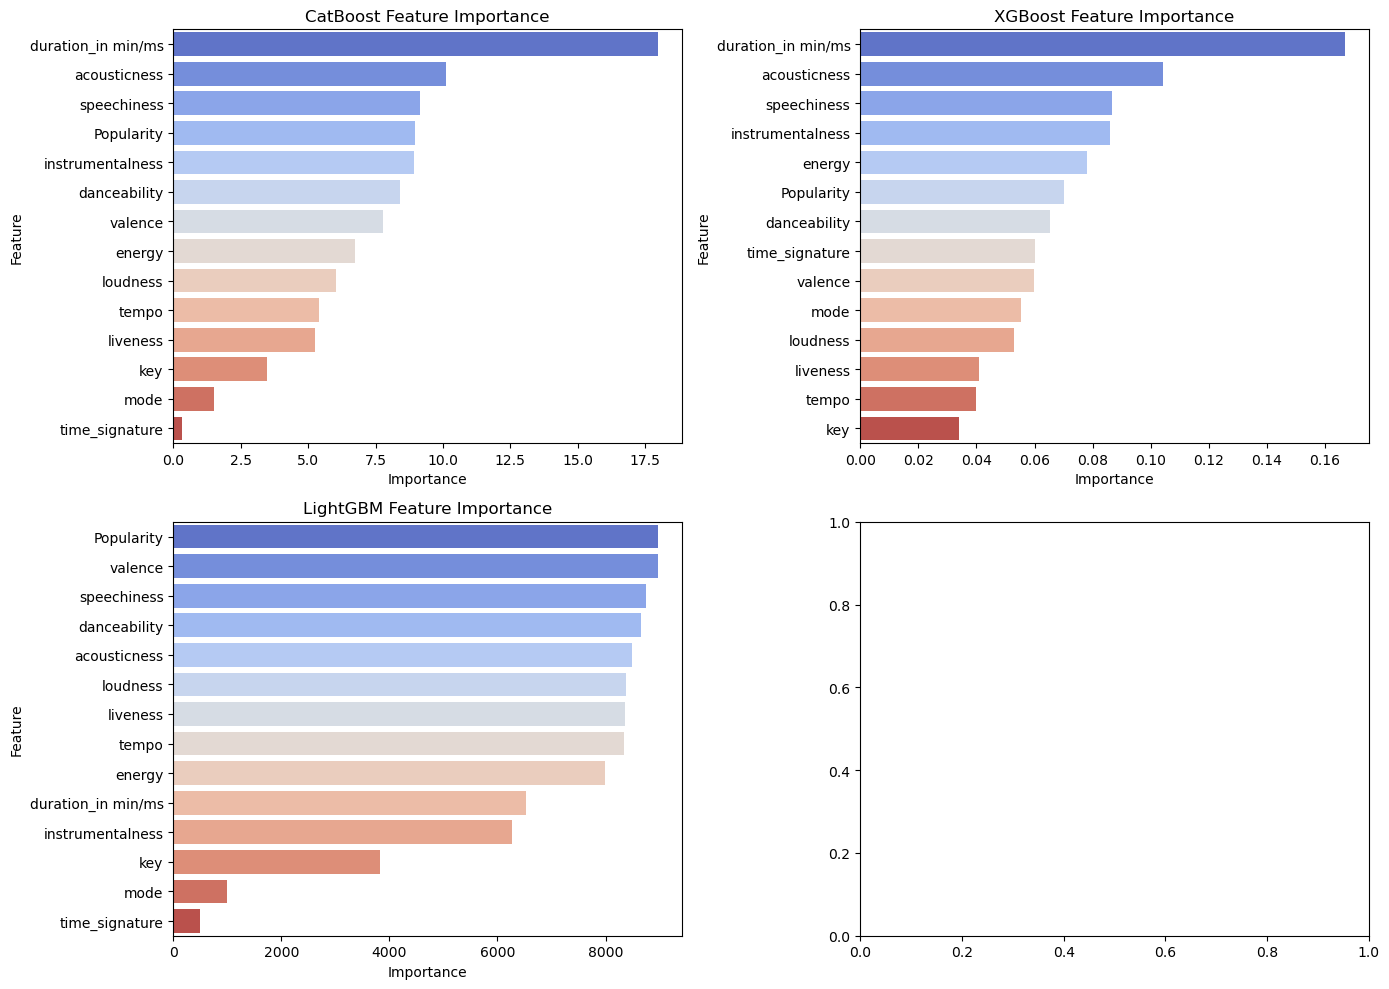

In [ ]:
import joblib

data_dir = join('..', '..', 'data')
df = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_train.csv"))
df = df.drop(['Id', 'Artist Name', 'Track Name', 'Class'], axis=1)
feature_names = df.columns.tolist()

models_to_check = ['CatBoost', 'XGBoost', 'LightGBM']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(models_to_check):
    model_path = join('..', '..', 'log', 'baseLine', 'Model Pickles', model_name, f'{model_name}_baseLine.pkl')
    model = joblib.load(model_path)
    
    importances = model.feature_importances_
    feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
    
    sns.barplot(data=feature_df, x='Importance', y='Feature', ax=axes[idx], palette='coolwarm')
    axes[idx].set_title(f'{model_name} Feature Importance')

plt.tight_layout()
plt.show()

Based on the result, it seems that `time_signature` have the lowest importance in 2/3 models. Because of that, we will try to remove that feature, and train models again using datasets after preprocessing progress.

In [ ]:
train = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_train.csv"))
train = train.drop(['Id', 'Artist Name', 'Track Name', 'time_signature'], axis=1)

test = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_test.csv"))
test = test.drop(['Artist Name', 'Track Name', 'time_signature'], axis=1)

In [ ]:
catboost(df=train, df_test=test)


==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5278 | prec:0.5803 | rec:0.5747 | f1:0.5745

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5210 | prec:0.5673 | rec:0.5512 | f1:0.5536

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5248 | prec:0.5698 | rec:0.5704 | f1:0.5656

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5144 | prec:0.5663 | rec:0.5603 | f1:0.5600

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5196 | prec:0.5733 | rec:0.5692 | f1:0.5664

==== Mean metrics ====
Acc: 0.5215
Prec: 0.5714
F1: 0.5640
Rec: 0.5652


In [ ]:
xgboost(df=train, df_test=test)


==== Fold 1 results for XGBClassifier ====
Fold 1 -> acc:0.4927 | prec:0.5726 | rec:0.5519 | f1:0.5592

==== Fold 2 results for XGBClassifier ====
Fold 2 -> acc:0.4891 | prec:0.5425 | rec:0.5216 | f1:0.5288

==== Fold 3 results for XGBClassifier ====
Fold 3 -> acc:0.4957 | prec:0.5461 | rec:0.5411 | f1:0.5400

==== Fold 4 results for XGBClassifier ====
Fold 4 -> acc:0.4894 | prec:0.5469 | rec:0.5361 | f1:0.5390

==== Fold 5 results for XGBClassifier ====
Fold 5 -> acc:0.4922 | prec:0.5564 | rec:0.5407 | f1:0.5447

==== Mean metrics ====
Acc: 0.4918
Prec: 0.5529
F1: 0.5424
Rec: 0.5383


In [ ]:
lightgbm(df=train, df_test=test)


==== Fold 1 results for LGBMClassifier ====
Fold 1 -> acc:0.5014 | prec:0.5884 | rec:0.5567 | f1:0.5675

==== Fold 2 results for LGBMClassifier ====
Fold 2 -> acc:0.4904 | prec:0.5566 | rec:0.5188 | f1:0.5334

==== Fold 3 results for LGBMClassifier ====
Fold 3 -> acc:0.5002 | prec:0.5573 | rec:0.5346 | f1:0.5412

==== Fold 4 results for LGBMClassifier ====
Fold 4 -> acc:0.5130 | prec:0.5788 | rec:0.5590 | f1:0.5660

==== Fold 5 results for LGBMClassifier ====
Fold 5 -> acc:0.5005 | prec:0.5732 | rec:0.5479 | f1:0.5557

==== Mean metrics ====
Acc: 0.5011
Prec: 0.5709
F1: 0.5528
Rec: 0.5434


In [ ]:
randomforest(df=train, df_test=test)


==== Fold 1 results for RandomForestClassifier ====
Fold 1 -> acc:0.5128 | prec:0.5859 | rec:0.5582 | f1:0.5639

==== Fold 2 results for RandomForestClassifier ====
Fold 2 -> acc:0.5071 | prec:0.5727 | rec:0.5392 | f1:0.5482

==== Fold 3 results for RandomForestClassifier ====
Fold 3 -> acc:0.5071 | prec:0.5590 | rec:0.5441 | f1:0.5457

==== Fold 4 results for RandomForestClassifier ====
Fold 4 -> acc:0.5102 | prec:0.5634 | rec:0.5512 | f1:0.5532

==== Fold 5 results for RandomForestClassifier ====
Fold 5 -> acc:0.5137 | prec:0.5756 | rec:0.5455 | f1:0.5523

==== Mean metrics ====
Acc: 0.5102
Prec: 0.5713
F1: 0.5527
Rec: 0.5476


Based on the result, the two models that have small improvement are LightGBM and Random Forest, but the improvements are too small to notice. Others have small decreasement.

It can be seen that this approach is not effective. More researches are needed.

### Feature `loudness_energy`

We decided to created new featurs with the hope to improve model's accuracy.

From the correlation heatmap, `energy` and `loudness` have high correlation. Because of that, we created new feature called `loudness_energy` 

$$loudness\_energy = energy + loudness$$

In [ ]:
train = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_train.csv"))
train = train.drop(['Id', 'Artist Name', 'Track Name'], axis=1)

test = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_test.csv"))
test = test.drop(['Artist Name', 'Track Name'], axis=1)

# Add new feature without reloading data
train['loudness_energy'] = train['energy'] + train['loudness']
test['loudness_energy'] = test['energy'] + test['loudness']

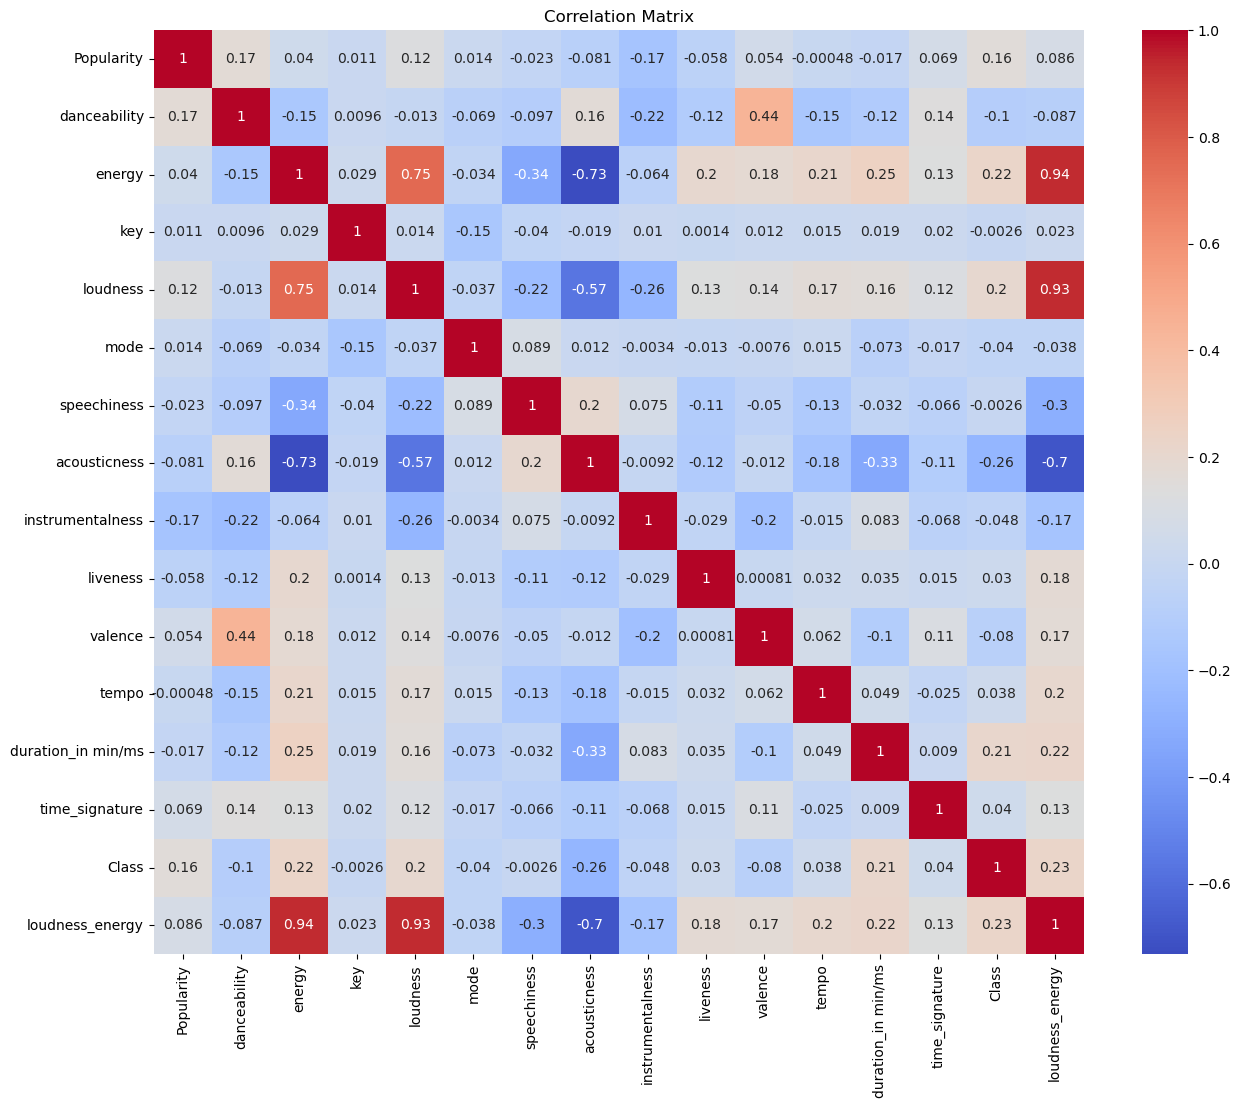

In [ ]:
plt.figure(figsize=(15,12))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Based on new generated correlation heatmap, the new feature is already shows it's effective, having highest correlation figure with Class feature

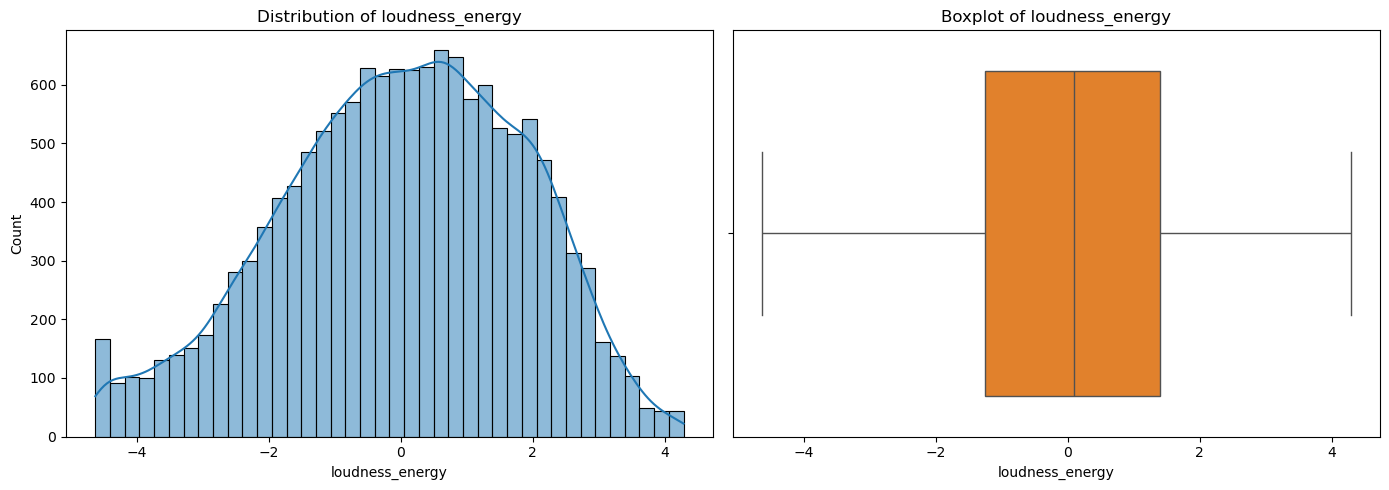

In [ ]:
# Distribution and boxplot for 'loudness_energy'
# Ensure the feature exists
# if 'loudness_energy' not in train.columns:
#     train['loudness_energy'] = train['energy'] + train['loudness']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(train['loudness_energy'].dropna(), bins=40, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribution of loudness_energy')
axes[0].set_xlabel('loudness_energy')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(x=train['loudness_energy'].dropna(), ax=axes[1], color='tab:orange')
axes[1].set_title('Boxplot of loudness_energy')
axes[1].set_xlabel('loudness_energy')

plt.tight_layout()
plt.show()

New feature's distribution is quite good, so no scaling technique is needed.

In [ ]:
print("CatBoost (no drop feature)")
catboost(df=train, df_test=test)

print("\nCatBoost (drop loudness + energy features)")
catboost(df=train.drop(['loudness', 'energy'], axis=1))

print("\nCatBoost (drop loudness features)")
catboost(df=train.drop(['loudness'], axis=1))

CatBoost (no drop feature)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5264 | prec:0.5812 | rec:0.5738 | f1:0.5739

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5221 | prec:0.5686 | rec:0.5553 | f1:0.5567

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5252 | prec:0.5628 | rec:0.5678 | f1:0.5622

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5193 | prec:0.5738 | rec:0.5665 | f1:0.5670

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5144 | prec:0.5707 | rec:0.5582 | f1:0.5591

==== Mean metrics ====
Acc: 0.5215
Prec: 0.5715
F1: 0.5638
Rec: 0.5643

CatBoost (drop loudness + energy features)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5170 | prec:0.5822 | rec:0.5718 | f1:0.5725

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5186 | prec:0.5620 | rec:0.5482 | f1:0.5504

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5228 | prec:0.5587 | rec:0.56

Base on the result, we can see that the result are quite similar to baseline, which is proved that pairs of features that have high correlation do not guarantee for improving model's accuracy when training.

### `energy` & `tempo`

#### Feature `energy_rempo_ration`

For this approach, we will focus on giving context for model that are displayed unclear in current dataset.

We will start by analyzing two features: `energy` and `tempo`.

Usually, we think songs that are rich in energy have fast tempo. However, based on the result from correlation matrix, the correlation figure between `energy` and `tempo` is not really high.

Because of that, it could be a good idea to create new feature that can show similarity between these two features.

Based on what we've analyze, we create new feature called `energy_tempo_ratio`
$$energy\_tempo\_ratio = energy / tempo$$

In [ ]:
train = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_train.csv"))
train = train.drop(['Id', 'Artist Name', 'Track Name'], axis=1)

test = pd.read_csv(join(data_dir, "preprocessed", "preprocessed_test.csv"))
test = test.drop(['Artist Name', 'Track Name'], axis=1)

train['energy_tempo_ratio'] = train['energy'] / (train['tempo'] + 1e-6)
test['energy_tempo_ratio'] = test['energy'] / (test['tempo'] + 1e-6)

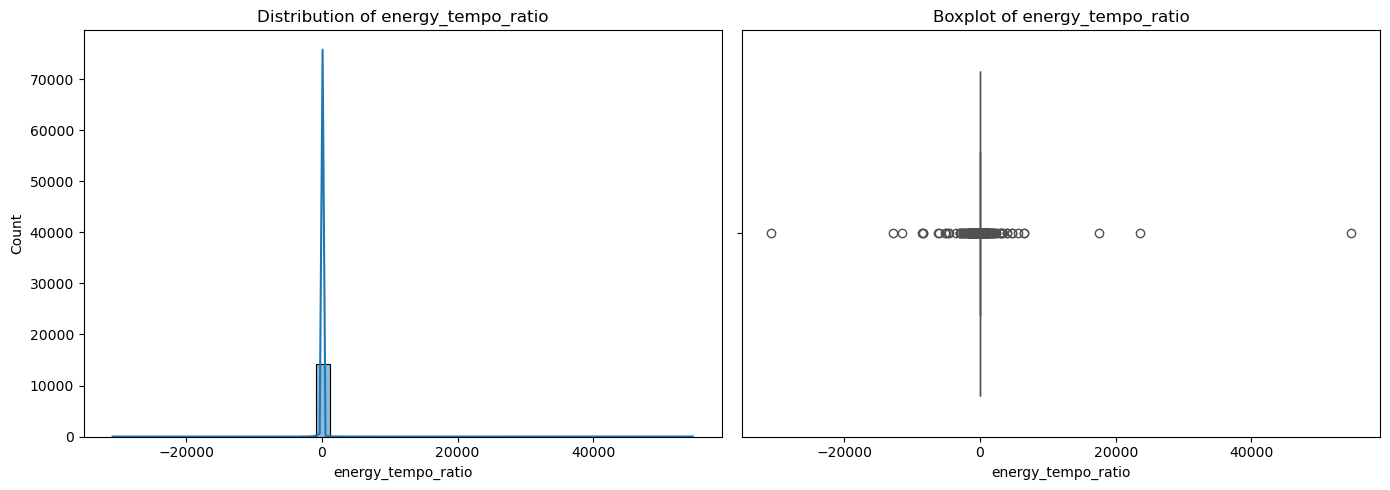

In [ ]:
# Distribution and boxplot for 'loudness_energy'
# Ensure the feature exists
# if 'loudness_energy' not in train.columns:
#     train['loudness_energy'] = train['energy'] + train['loudness']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(train['energy_tempo_ratio'].dropna(), bins=40, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribution of energy_tempo_ratio')
axes[0].set_xlabel('energy_tempo_ratio')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(x=train['energy_tempo_ratio'].dropna(), ax=axes[1], color='tab:orange')
axes[1].set_title('Boxplot of energy_tempo_ratio')
axes[1].set_xlabel('energy_tempo_ratio')

plt.tight_layout()
plt.show()

The histogram and boxplot show a huge spike near 0 with some extremely large positive and negative values (tens of thousands). Because of that, we need to handle outlier values

In [ ]:
def cat_outliers_iqr(df, col):
    df_clean = df.copy()
    
    # 1. Tính toán IQR
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Xác định giới hạn
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 3. Đếm số lượng outlier trước khi xử lý (để theo dõi)
    outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    if outliers_count > 0:
        # 4. Capping (Gán giá trị)
        # Dùng np.where: Nếu > upper thì lấy upper, ngược lại giữ nguyên
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
        
        # Nếu < lower thì lấy lower, ngược lại giữ nguyên
        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
    return df_clean

train = cat_outliers_iqr(train, 'energy_tempo_ratio')
test = cat_outliers_iqr(test, 'energy_tempo_ratio')

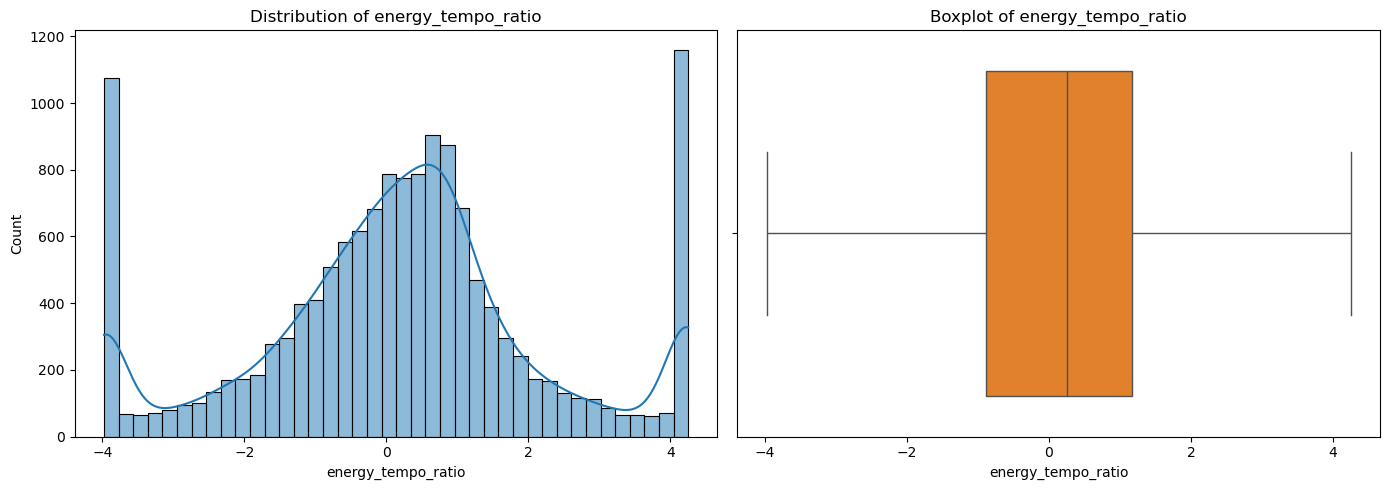

In [ ]:
# Distribution and boxplot for 'loudness_energy'
# Ensure the feature exists
# if 'loudness_energy' not in train.columns:
#     train['loudness_energy'] = train['energy'] + train['loudness']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(train['energy_tempo_ratio'].dropna(), bins=40, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribution of energy_tempo_ratio')
axes[0].set_xlabel('energy_tempo_ratio')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(x=train['energy_tempo_ratio'].dropna(), ax=axes[1], color='tab:orange')
axes[1].set_title('Boxplot of energy_tempo_ratio')
axes[1].set_xlabel('energy_tempo_ratio')

plt.tight_layout()
plt.show()

After finishing outlier handling, the distribution of `energy_tempo_ratio` is improve.

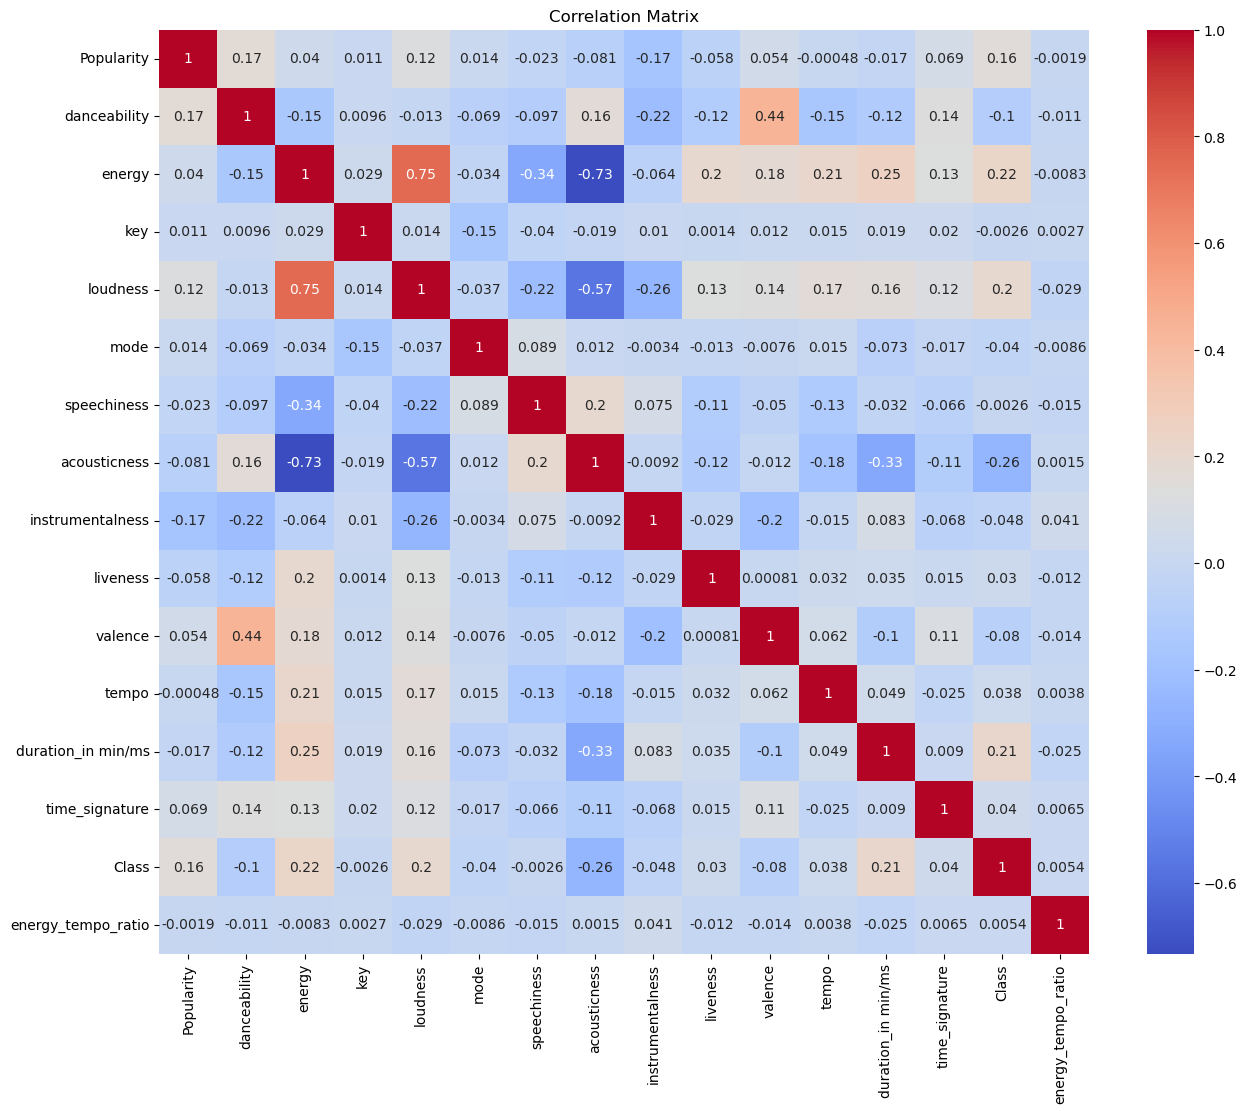

In [ ]:
plt.figure(figsize=(15,12))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

As we can see, the correlation figures between `energy_tempo_ratio` and others is very low, which is expected.

In [ ]:
print("CatBoost (no drop feature)")
catboost(df=train, df_test=test)

CatBoost (no drop feature)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5226 | prec:0.5799 | rec:0.5699 | f1:0.5708

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5182 | prec:0.5676 | rec:0.5489 | f1:0.5534

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5294 | prec:0.5713 | rec:0.5742 | f1:0.5686

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5231 | prec:0.5739 | rec:0.5706 | f1:0.5691

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5241 | prec:0.5753 | rec:0.5652 | f1:0.5656

==== Mean metrics ====
Acc: 0.5235
Prec: 0.5736
F1: 0.5655
Rec: 0.5658


Based on the result, it can be seen that the validation scores is improved compared to that of baseline (both are run by CatBoostClassifier), although the changes are small:

- Accuracy: 0.5235 > 0.5222
- Precision: 0.5736 > 0.5728
- F1-Score: 0.5655 < 0.5656
- Recall Score: 0.5658 < 0.5666

In [ ]:
print("\nCatBoost (drop tempo + energy features)")
catboost(df=train.drop(['tempo', 'energy'], axis=1))

print("\nCatBoost (drop tempo features)")
catboost(df=train.drop(['tempo'], axis=1))


CatBoost (drop tempo + energy features)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5174 | prec:0.5802 | rec:0.5640 | f1:0.5674

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5106 | prec:0.5582 | rec:0.5416 | f1:0.5451

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5158 | prec:0.5534 | rec:0.5561 | f1:0.5515

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5130 | prec:0.5608 | rec:0.5624 | f1:0.5582

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5172 | prec:0.5723 | rec:0.5634 | f1:0.5638

==== Mean metrics ====
Acc: 0.5148
Prec: 0.5650
F1: 0.5572
Rec: 0.5575

CatBoost (drop tempo features)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5163 | prec:0.5723 | rec:0.5656 | f1:0.5659

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5196 | prec:0.5649 | rec:0.5466 | f1:0.5508

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5234 | prec:0.5665 | rec:0.

The result is lower than baseline, which is expected as the correlation between new feature and dropped features are not high

#### Feature `energy_tempo_prod`

In [ ]:
df = train.copy()
df_test = train.copy()

df['energy_tempo_prod'] = df['energy'] * df['tempo']
df_test['energy_tempo_prod'] = df_test['energy'] * df_test['tempo']

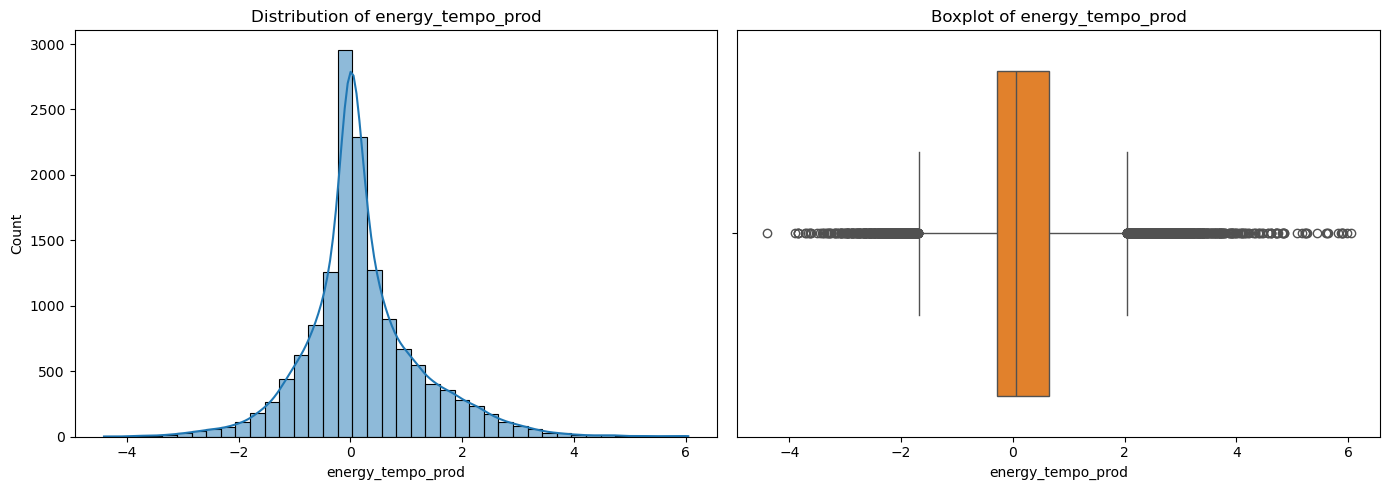

In [ ]:
# Distribution and boxplot for 'loudness_energy'
# Ensure the feature exists
# if 'loudness_energy' not in train.columns:
#     train['loudness_energy'] = train['energy'] + train['loudness']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(df['energy_tempo_prod'].dropna(), bins=40, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribution of energy_tempo_prod')
axes[0].set_xlabel('energy_tempo_prod')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(x=df['energy_tempo_prod'].dropna(), ax=axes[1], color='tab:orange')
axes[1].set_title('Boxplot of energy_tempo_prod')
axes[1].set_xlabel('energy_tempo_prod')

plt.tight_layout()
plt.show()

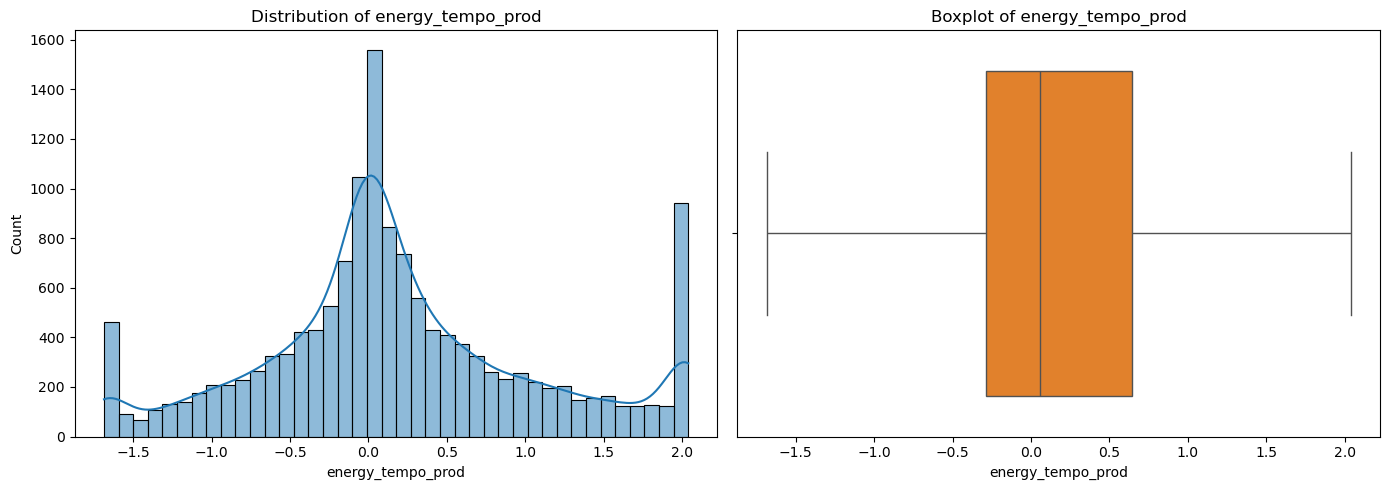

In [ ]:
df = cat_outliers_iqr(df, 'energy_tempo_prod')
df_test = cat_outliers_iqr(df_test, 'energy_tempo_prod')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(df['energy_tempo_prod'].dropna(), bins=40, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribution of energy_tempo_prod')
axes[0].set_xlabel('energy_tempo_prod')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(x=df['energy_tempo_prod'].dropna(), ax=axes[1], color='tab:orange')
axes[1].set_title('Boxplot of energy_tempo_prod')
axes[1].set_xlabel('energy_tempo_prod')

plt.tight_layout()
plt.show()

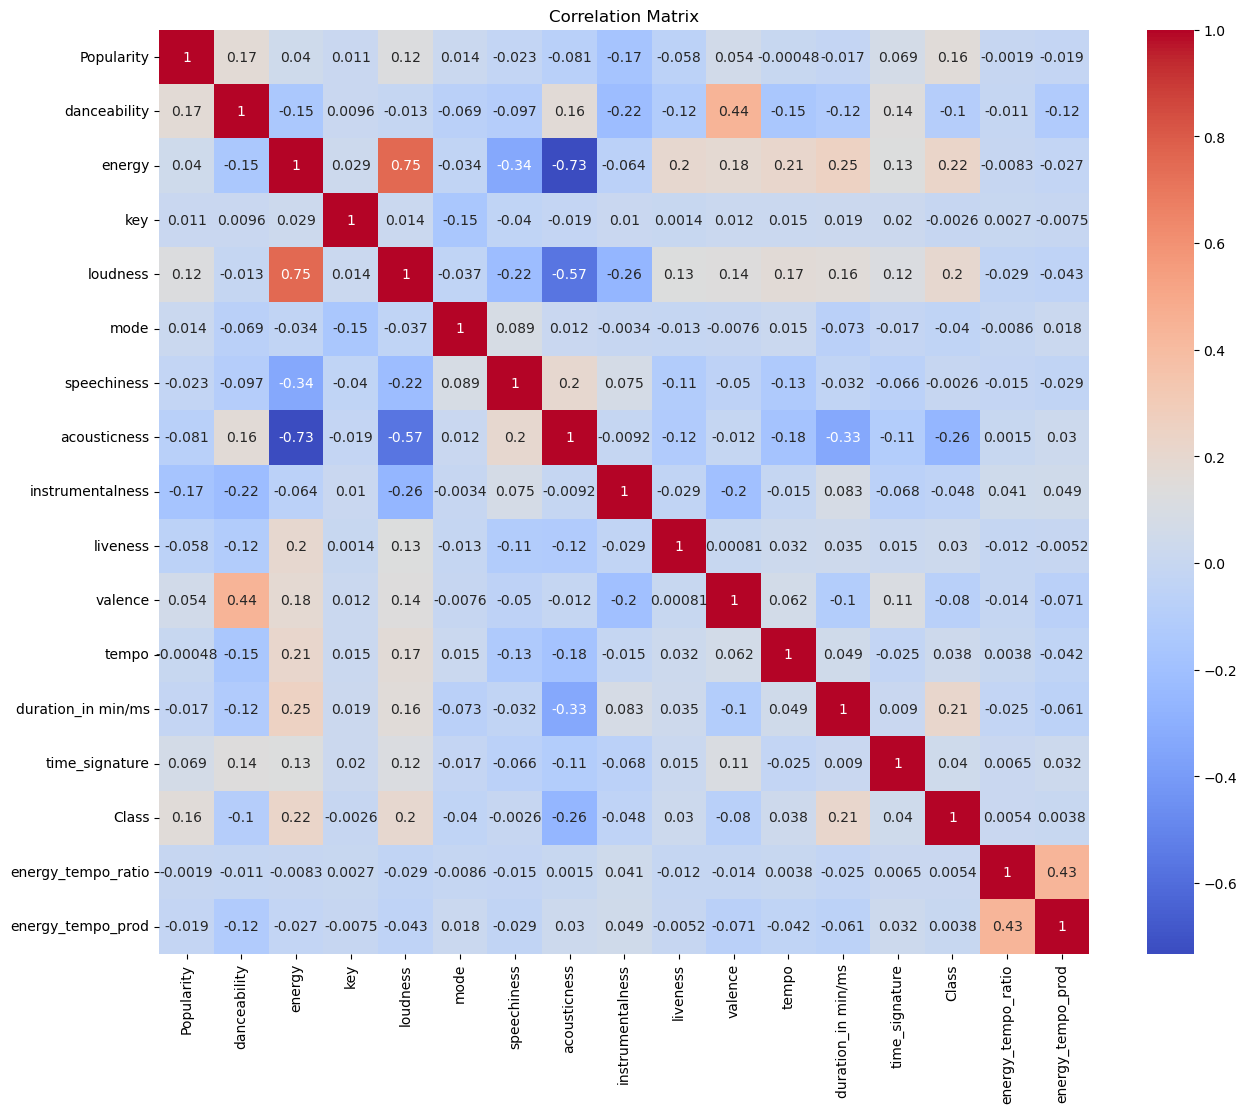

In [ ]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
catboost(df=df.drop(['energy_tempo_ratio'], axis=1), df_test=df_test.drop(['energy_tempo_ratio'], axis=1))

CatBoost (no drop feature)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5222 | prec:0.5790 | rec:0.5738 | f1:0.5729

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5175 | prec:0.5692 | rec:0.5520 | f1:0.5559

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5273 | prec:0.5662 | rec:0.5672 | f1:0.5630

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5203 | prec:0.5711 | rec:0.5667 | f1:0.5657

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5231 | prec:0.5776 | rec:0.5640 | f1:0.5655

==== Mean metrics ====
Acc: 0.5221
Prec: 0.5726
F1: 0.5646
Rec: 0.5647


### `energy` & `instrumentalness`

Pairwise features like `energy` and `instrumentalness` can highlight genres where energetic music is mostly instrumental or not.

#### Feature `energy_instrumental_ratio`

$$energy\_instrumental\_ratio = energy / instrumentalness$$

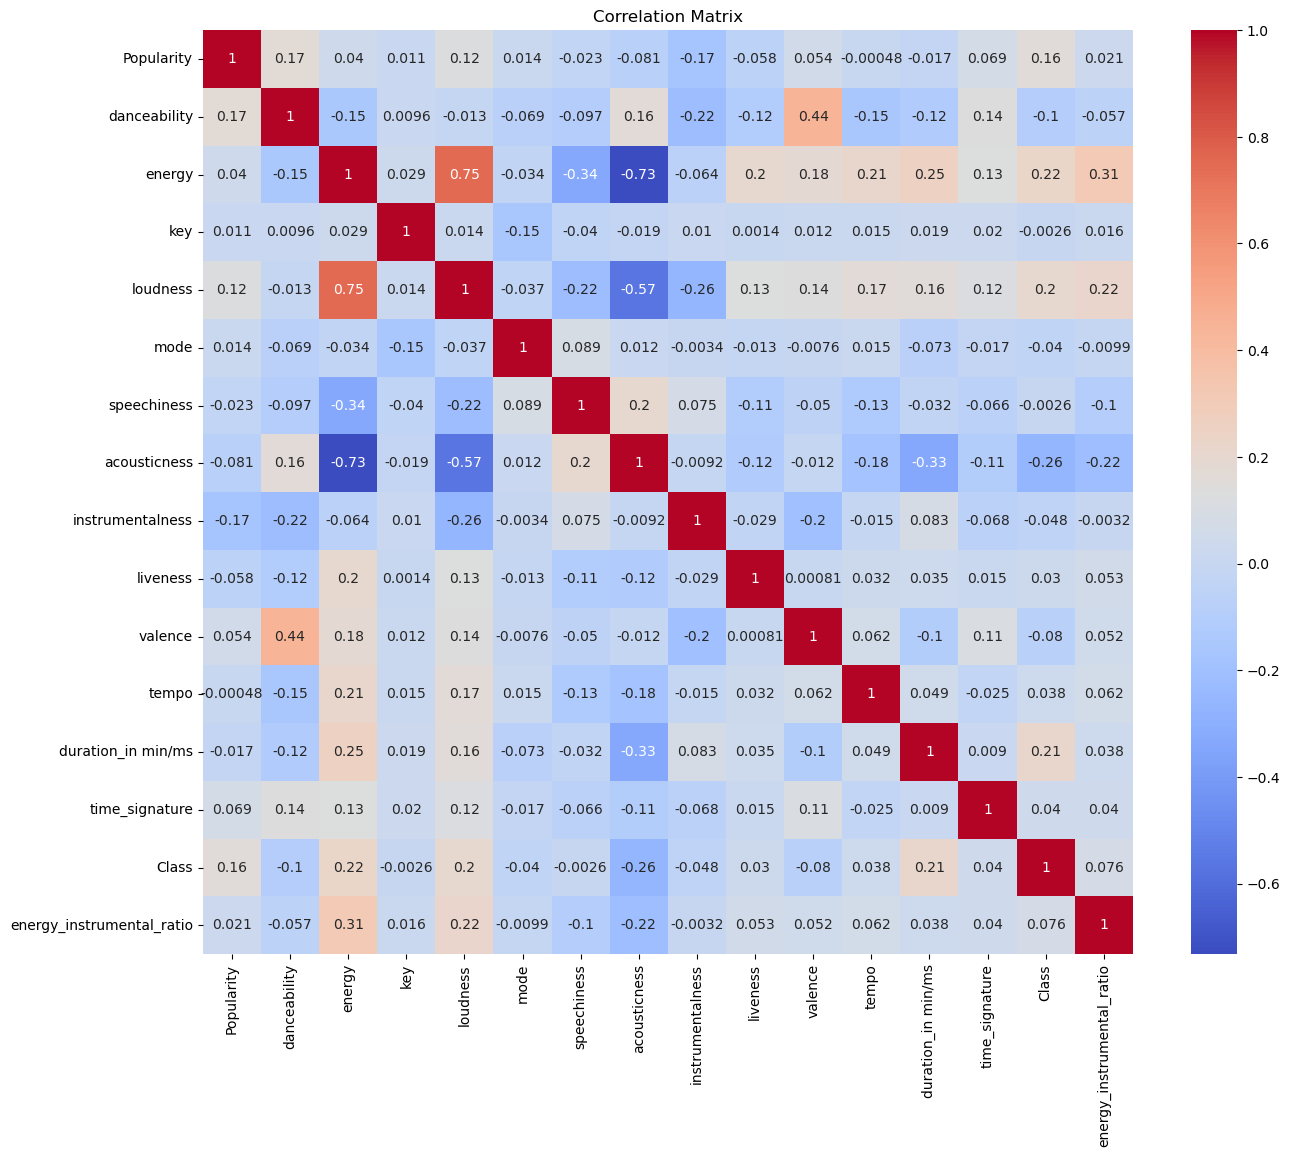

In [ ]:
df = train.copy()
df_test = test.copy()
# df = df.drop(['Id', 'Artist Name', 'Track Name'], axis=1)
# df_test = df_test.drop(['Id', 'Artist Name', 'Track Name'], axis=1)
df['energy_instrumental_ratio'] = df['energy'] / (df['instrumentalness'] + 1e-6)
df_test['energy_instrumental_ratio'] = df_test['energy'] / (df_test['instrumentalness'] + 1e-6)

cat_outliers_iqr(df, 'energy_instrumental_ratio')
cat_outliers_iqr(df_test, 'energy_instrumental_ratio')

plt.figure(figsize=(15,12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
catboost(df=df.drop(['energy_tempo_ratio'], axis=1), df_test=df_test.drop(['energy_tempo_ratio'], axis=1))

CatBoost (no drop feature)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5257 | prec:0.5764 | rec:0.5716 | f1:0.5712

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5189 | prec:0.5691 | rec:0.5499 | f1:0.5544

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5290 | prec:0.5768 | rec:0.5768 | f1:0.5728

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5210 | prec:0.5753 | rec:0.5714 | f1:0.5702

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5217 | prec:0.5777 | rec:0.5679 | f1:0.5670

==== Mean metrics ====
Acc: 0.5233
Prec: 0.5750
F1: 0.5671
Rec: 0.5675


This new features show high development in validation score compared to baseline

In [ ]:
catboost(df=df, df_test=df_test)

CatBoost (no drop feature)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5219 | prec:0.5751 | rec:0.5710 | f1:0.5691

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5224 | prec:0.5736 | rec:0.5505 | f1:0.5564

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5262 | prec:0.5657 | rec:0.5685 | f1:0.5635

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5193 | prec:0.5669 | rec:0.5647 | f1:0.5633

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5276 | prec:0.5795 | rec:0.5711 | f1:0.5699

==== Mean metrics ====
Acc: 0.5235
Prec: 0.5722
F1: 0.5644
Rec: 0.5652


The validation score drop this time. This means that feature `energy_tempo_ratio` affects negatively on the model's accuracy.

Because of that, we decided to get rid of that feature.

In [ ]:
train = df.drop(['energy_tempo_ratio'], axis=1).copy()
test = df_test.drop(['energy_tempo_ratio'], axis=1).copy()

#### Feature `energy_instrumental_prod`

$$energy\_instrumental\_prod = energy * instrumentalness$$

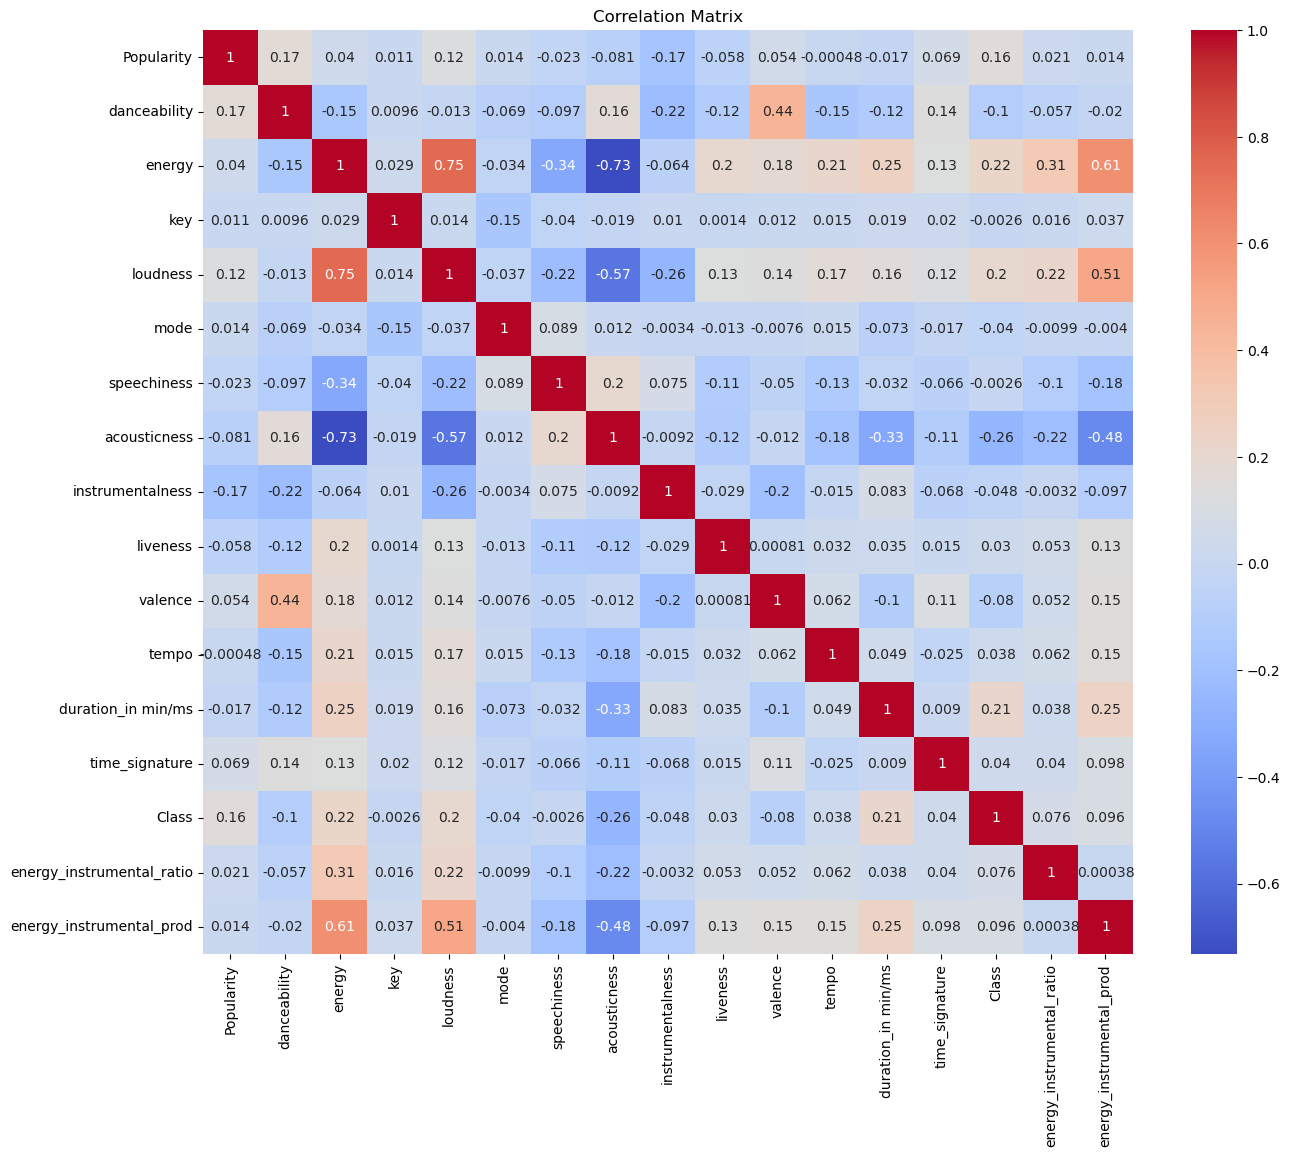

In [ ]:
df = train.copy()
df_test = test.copy()
df['energy_instrumental_prod'] = df['energy'] * df['instrumentalness']
df_test['energy_instrumental_prod'] = df_test['energy'] * df_test['instrumentalness']

cat_outliers_iqr(df, 'energy_instrumental_prod')
cat_outliers_iqr(df_test, 'energy_instrumental_prod')

plt.figure(figsize=(15,12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
print("CatBoost (no drop feature)")
catboost(df=df.drop(['energy_instrumental_ratio'], axis=1), df_test=df_test.drop(['energy_instrumental_ratio'], axis=1))

CatBoost (no drop feature)

==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5233 | prec:0.5806 | rec:0.5735 | f1:0.5735

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5172 | prec:0.5669 | rec:0.5458 | f1:0.5508

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5294 | prec:0.5698 | rec:0.5690 | f1:0.5659

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5162 | prec:0.5704 | rec:0.5633 | f1:0.5640

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5186 | prec:0.5761 | rec:0.5668 | f1:0.5665

==== Mean metrics ====
Acc: 0.5209
Prec: 0.5728
F1: 0.5641
Rec: 0.5637


The validation score is lower than baseline.

After the experiment, I will keep `energy_tempo_ratio` as the new feature.

In [ ]:
# train = train.drop(['energy_instrumental_prod'], axis=1)
# test = test.drop(['energy_instrumental_prod'], axis=1)

train.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,energy_instrumental_ratio
0,37.0,0.334,-0.676218,9.0,0.153284,0,26.246030,0.723043,0.003912,-0.598627,0.235,1.014464,452.710724,4,-172.798348
1,67.0,0.725,0.256062,11.0,0.523145,1,11.415395,0.300739,0.045738,-0.629790,0.380,0.425560,438.127835,4,5.598346
2,44.0,0.584,0.550185,7.0,0.332191,1,16.154828,0.098922,0.139563,1.055408,0.635,1.226456,401.294156,4,3.942170
3,12.0,0.515,-1.433464,-1.0,-1.572682,1,32.050255,0.967986,0.021076,1.134827,0.501,1.563116,545.978937,3,-68.009788
4,48.0,0.565,0.408517,6.0,0.691321,0,4.016048,0.567741,0.003912,0.583192,0.619,-1.217968,504.127960,4,104.390870


## Modelling

In [ ]:
catboost(df=train, df_test=test)
xgboost(df=train, df_test=test)
lightgbm(df=train, df_test=test)
randomforest(df=train, df_test=test)


==== Fold 1 results for CatBoostClassifier ====
Fold 1 -> acc:0.5257 | prec:0.5764 | rec:0.5716 | f1:0.5712

==== Fold 2 results for CatBoostClassifier ====
Fold 2 -> acc:0.5189 | prec:0.5691 | rec:0.5499 | f1:0.5544

==== Fold 3 results for CatBoostClassifier ====
Fold 3 -> acc:0.5290 | prec:0.5768 | rec:0.5768 | f1:0.5728

==== Fold 4 results for CatBoostClassifier ====
Fold 4 -> acc:0.5210 | prec:0.5753 | rec:0.5714 | f1:0.5702

==== Fold 5 results for CatBoostClassifier ====
Fold 5 -> acc:0.5217 | prec:0.5777 | rec:0.5679 | f1:0.5670

==== Mean metrics ====
Acc: 0.5233
Prec: 0.5750
F1: 0.5671
Rec: 0.5675

==== Fold 1 results for XGBClassifier ====
Fold 1 -> acc:0.5049 | prec:0.5843 | rec:0.5665 | f1:0.5722

==== Fold 2 results for XGBClassifier ====
Fold 2 -> acc:0.4925 | prec:0.5488 | rec:0.5268 | f1:0.5349

==== Fold 3 results for XGBClassifier ====
Fold 3 -> acc:0.4964 | prec:0.5518 | rec:0.5442 | f1:0.5445

==== Fold 4 results for XGBClassifier ====
Fold 4 -> acc:0.4967 | prec

Based on the output, it seems to us that only CatBoost and XGBoost model does have improvement in accuracy.

## Submit

In [ ]:
output_dir = join(data_dir, 'submissions')

catboost(
    df=train,
    df_test=test,
    author="Thien",
    path_to_log_csv=join('..', '..', 'log', 'energy', 'experiment_logger.csv'),
    name_folder="energy",
    name_feature='energy_instrumental_ratio',
    print_log=False,
    save_log=True,
    save_model=True,
    save_submission=True
)

xgboost(
    df=train,
    df_test=test,
    author="Thien",
    path_to_log_csv=join('..', '..', 'log', 'energy', 'experiment_logger.csv'),
    name_folder="energy",
    name_feature='energy_instrumental_ratio',
    print_log=False,
    save_log=True,
    save_model=True,
    save_submission=True
)

lightgbm(
    df=train,
    df_test=test,
    author="Thien",
    path_to_log_csv=join('..', '..', 'log', 'energy', 'experiment_logger.csv'),
    name_folder="energy",
    name_feature='energy_instrumental_ratio',
    print_log=False,
    save_log=True,
    save_model=True,
    save_submission=True
)

randomforest(
    df=train,
    df_test=test,
    author="Thien",
    path_to_log_csv=join('..', '..', 'log', 'energy', 'experiment_logger.csv'),
    name_folder="energy",
    name_feature='energy_instrumental_ratio',
    print_log=False,
    save_log=True,
    save_model=True,
    save_submission=True
)

Logged experiment to ..\..\log\energy\experiment_logger.csv
✅ Model saved to ..\..\log\energy\Model Pickles\CatBoostClassifier\CatBoostClassifier_energy_instrumental_ratio.pkl
📤 Submission file saved to ..\..\data\submissions\energy\CatBoostClassifier\submission_CatBoostClassifier_energy_instrumental_ratio.csv
Logged experiment to ..\..\log\energy\experiment_logger.csv
✅ Model saved to ..\..\log\energy\Model Pickles\XGBClassifier\XGBClassifier_energy_instrumental_ratio.pkl
📤 Submission file saved to ..\..\data\submissions\energy\XGBClassifier\submission_XGBClassifier_energy_instrumental_ratio.csv
Logged experiment to ..\..\log\energy\experiment_logger.csv
✅ Model saved to ..\..\log\energy\Model Pickles\LGBMClassifier\LGBMClassifier_energy_instrumental_ratio.pkl
📤 Submission file saved to ..\..\data\submissions\energy\LGBMClassifier\submission_LGBMClassifier_energy_instrumental_ratio.csv
Logged experiment to ..\..\log\energy\experiment_logger.csv
✅ Model saved to ..\..\log\energy\Model 

## Result

<img src="images/output_kaggle_energy.png" width="800">

Although the CatBoost's validation score when using this dataset is higher than that of baseline, the test score is lower. Only XGBoost score is increase.

In [ ]:
df.to_csv(join(data_dir, "feature_engineered", "energy", "energy_train.csv"), index=False)
df_test.to_csv(join(data_dir, "feature_engineered", "energy", "energy_test.csv"), index=False)

# The end